<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH04/CH04_NB01_Cosine_Similarity_lmeval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 4: Depth Pruning: Building Smaller and Faster Models

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
* Qwen3-0.6B
_____

In this notebook we explore how to evaluate the contribution of different transformer blocks to the LLM's objective using a dataset.

To do this, we use cosine similarity between the input and the output of the transformer block. The lower the similarity, the greater the modification that block has introduced to the data.

Blocks with higher similarity between input and output will be the candidates to be removed from the model.

In this version, calibration is done with **Winogrande** prompts, showing how data-driven pruning preserves task-relevant behavior for pronoun/coreference resolution inputs.

## Setting up notebook

In [ ]:
!pip install -q \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "sentence-transformers==5.1.0" \
      "datasets==3.5.0" \
      "optipfair==0.1.5"

In [ ]:
import torch, random
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM
import os
import json
from copy import deepcopy
from optipfair import analyze_layer_importance, prune_model_depth, prune_model

In [ ]:
# ── Global Configuration ─────────────────────────────────────────────────────
MODEL_NAME          = "Qwen/Qwen3-0.6B"
SEED                = 42

# Calibration dataset parameters
CALIBRATION_SAMPLES = 1000
BATCH_SIZE          = 4
MAX_LENGTH          = 512        # Winogrande prompts fit comfortably in this context window

# lm_eval parameters
BENCHMARK_LIMIT     = None       # Samples per benchmark task
BENCHMARK_TASKS = ['winogrande', 'boolq', 'arc_easy',
                   'hellaswag', 'lambada_openai']

In [ ]:
def set_reproducibility(seed=42):
    # 1. Seed for Python and basic libraries
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    # 2. Seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU
    # 3. Configure cuDNN to be deterministic
    # Note: This may slow down training slightly
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # 4. Seed for Transformers (Hugging Face)
    set_seed(seed)
    print(f"\u2705  Seed {seed} stablished.")

set_reproducibility(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅  Seed 42 stablished.
Using device: cuda
GPU: NVIDIA L4


In [ ]:
def evaluate_metrics(model, dataloader, device='cuda'):
    model.eval()
    model.to(device)
    total_loss = 0
    total_tokens = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Create labels, ignoring padding (-100 = ignore_index)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100
            # Forward pass
            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            # Only real tokens (no padding)
            num_real_tokens = attention_mask.sum().item()
            total_loss += outputs.loss.item() * num_real_tokens
            total_tokens += num_real_tokens
    # metrics
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return {
        'loss': avg_loss,
        'perplexity': perplexity
    }

 ## Load Model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## Load Datasets

We use the **Winogrande** dataset for calibration in this notebook. Because pruning decisions are computed from this data distribution, the selected layers reflect Winogrande-style coreference prompts.

- **Winogrande**: Sentence completion with binary options focused on pronoun/coreference understanding.

The prompts are formatted consistently with the evaluation flow so calibration and downstream comparisons share a similar input style.

In [ ]:
# Winogrande: coreference resolution (binary choice)
raw_winogrande = load_dataset('winogrande', 'winogrande_xl', split=f'train[:{CALIBRATION_SAMPLES}]', trust_remote_code=True)

def format_winogrande(example):
    option1 = example['option1']
    option2 = example['option2']
    answer = example['answer']  # '1' or '2'
    answer_text = option1 if answer == '1' else option2

    example['text'] = (
        f"Sentence: {example['sentence']}\n"
        f"Option 1: {option1}\n"
        f"Option 2: {option2}\n"
        f"Answer: {answer}. {answer_text}"
    )
    return example

datawinogrande = raw_winogrande.map(format_winogrande)

In [ ]:
datawinogrande[0]

{'sentence': "Ian volunteered to eat Dennis's menudo after already having a bowl because _ despised eating intestine.",
 'option1': 'Ian',
 'option2': 'Dennis',
 'answer': '2',
 'text': "Sentence: Ian volunteered to eat Dennis's menudo after already having a bowl because _ despised eating intestine.\nOption 1: Ian\nOption 2: Dennis\nAnswer: 2. Dennis"}

In [ ]:
def prepare_dataset(dataset, text_field='text'):
    def tokenize_function(examples):
        texts = examples[text_field]
        return tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors=None  # Lists, not tensors — avoids torch_formatter
        )
    tokenized = dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

    # Convert to tensors manually in collate_fn
    def collate_fn(examples):
        input_ids = torch.tensor([e['input_ids'] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e['attention_mask'] for e in examples], dtype=torch.long)
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

    return DataLoader(tokenized, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Create dataloader
dataloaderwinogrande = prepare_dataset(datawinogrande)  # Winogrande calibration prompts

## 4.2 Static block selection

Static approaches are those based on analyzing the structure and initial weights of the model.

### 4.2.1 Removing first, last, middle blocks

In [ ]:
# Based in position.
num_to_remove = 4
num_layers = len(model.model.layers)

# Calculate mid point
mid_point = num_layers // 2

# Calculate start and end
start_remove_index = mid_point - (num_to_remove // 2)
end_remove_index = start_remove_index + num_to_remove
static_position_layers_removed = list(range(start_remove_index, end_remove_index))

print(f"Number of layers: {num_layers}")
print(f"Layers to remove {num_to_remove}.")
print(f"removing from {start_remove_index} to {end_remove_index - 1}")

pruned_model = deepcopy(model)
layers_before = pruned_model.model.layers[:start_remove_index]
layers_after = pruned_model.model.layers[end_remove_index:]

# Assign layers to the model.
pruned_model.model.layers = layers_before + layers_after
print(f"Layers in pruned model: {len(pruned_model.model.layers)}")
print(f"Removed layers: {num_layers - len(pruned_model.model.layers)}")

metrics_pruned_static_winogrande = evaluate_metrics(pruned_model, dataloaderwinogrande)
metrics_pruned_static_winogrande

Number of layers: 28
Layers to remove 4.
removing from 12 to 15
Layers in pruned model: 24
Removed layers: 4


Evaluating: 100%|██████████| 250/250 [00:28<00:00,  8.77it/s]


{'loss': 3.955575397861314, 'perplexity': np.float64(52.2257358773002)}

In [ ]:
# Based in weights
def calculate_layer_magnitude(layer):
    total_magnitude = 0
    for param in layer.parameters():
        total_magnitude += torch.norm(param).item()
    return total_magnitude

# Calculate magnitude for each layer
layer_magnitudes = []
for i, layer in enumerate(model.model.layers):
    magnitude = calculate_layer_magnitude(layer)
    layer_magnitudes.append((i, magnitude))

# Remove layers with lower magnitude
layer_magnitudes.sort(key=lambda x: x[1])  # Sort by magnitude
layers_to_remove = [idx for idx, _ in layer_magnitudes[:4]]  # Remove layers with lower magnitude
print(layers_to_remove)

[8, 2, 7, 6]


In [ ]:
def print_sorted_importance(scores):
    for i, (layer, score) in enumerate(sorted(scores.items(), key=lambda x: float(x[1]), reverse=True), 1):
        print(f"Layer {layer:2d}: {float(score):.6f}")

In [ ]:
# Normalize each layer's total parameter magnitude by the maximum observed magnitude.
# Using divide-by-max so that 1.0 = the heaviest layer and 0.0 would only occur
# for a truly empty layer (never in practice).
layer_magnitudes_raw = []
for i, layer in enumerate(model.model.layers):
    magnitude = calculate_layer_magnitude(layer)
    layer_magnitudes_raw.append((i, magnitude))

max_magnitude = max(mag for _, mag in layer_magnitudes_raw)
weight_importance = {i: mag / max_magnitude for i, mag in layer_magnitudes_raw}

print("Weight importance (magnitude-based, normalized):")
print_sorted_importance(weight_importance)

Weight importance (magnitude-based, normalized):
Layer 26: 1.000000
Layer 27: 0.988851
Layer 25: 0.897940
Layer 24: 0.773582
Layer 23: 0.660779
Layer 22: 0.617531
Layer 21: 0.586590
Layer 20: 0.523521
Layer 19: 0.499370
Layer 17: 0.472382
Layer 18: 0.457614
Layer 15: 0.424255
Layer  0: 0.424041
Layer 16: 0.408314
Layer 12: 0.391605
Layer 14: 0.390852
Layer  5: 0.390838
Layer  4: 0.387225
Layer  9: 0.384858
Layer 11: 0.384829
Layer 10: 0.383743
Layer 13: 0.383555
Layer  1: 0.377460
Layer  3: 0.374057
Layer  6: 0.372754
Layer  7: 0.371987
Layer  2: 0.367799
Layer  8: 0.361403


In [ ]:
magnitude_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=layers_to_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 469762.05it/s]


## 4.3 Data-Driven block selection

To decide which layers to remove, we measure their contribution using cosine similarity. We chose this metric because it's perfect for this task: it measures the change in semantic direction between the input and output vectors of a layer, ignoring their magnitude.

This gives us a normalized score that we convert into an importance score (1 - similarity).

A score close to zero identifies a \"passive\" layer that barely alters the information, making it an ideal candidate for removal.

### 4.3.1 Using PyTorch hooks

We define a simple function to use as a hook that shows the shape of the input tensor and the output tensor.

In [ ]:
def print_shape_hook(module, input, output):
    """
    Hook function that prints tensor shapes
    module: the layer where the hook is attached
    input: tuple of input tensors to the layer
    output: the output tensor from the layer
    """
    # Input is a tuple, we take the first element (the hidden states)
    print(f"Module class: {module.__class__.__name__}")
    print(f"Module id: {id(module)}")
    input_tensor = input[0]
    print(f"Input shape:  {input_tensor.shape}")
    print(f"Output shape: {output.shape}")

We register the hook in the first transformer block.

In [ ]:
# Register the hook on the first transformer block
first_layer = model.model.layers[0]
hook_handle = first_layer.register_forward_hook(print_shape_hook)

# Test with a simple input
test_text = "He sat on the river bank to fish"
inputs = tokenizer(test_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# Remove the hook when done
hook_handle.remove()

# If we run the forward again, the hook no longer executes
with torch.no_grad():
    outputs = model(**inputs)

Module class: Qwen3DecoderLayer
Module id: 134368638167152
Input shape:  torch.Size([1, 8, 1024])
Output shape: torch.Size([1, 8, 1024])


### 4.3.2 Understanding cosine similarity.

In [ ]:
from sentence_transformers import SentenceTransformer

# Load standard sentence embedding model
modelst = SentenceTransformer('all-MiniLM-L6-v2')

# Three example sentences: two semantically similar, one different
sentences = [
    "The cat naps on the sofa.",
    "The feline is peacefully slumbering on the couch.",
    "The bus stops at the corner."
]

embeddings = modelst.encode(sentences, convert_to_tensor=True)
print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by {embeddings.shape[1]} dimensions\n")

# Calculate cosine similarity matrix using PyTorch
# We need to compute all pairs, so we use matrix multiplication
# First normalize embeddings
embeddings_normalized = F.normalize(embeddings, p=2, dim=1)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: torch.Size([3, 384])
Each sentence is represented by 384 dimensions



In [ ]:
# Compute similarity matrix (cosine = dot product of normalized vectors)
similarity_matrix = torch.mm(embeddings_normalized, embeddings_normalized.T)

print("Cosine Similarity Matrix:")
print(similarity_matrix)
print("\nInterpretation:")
print(f"Sentence 1 vs Sentence 2: {similarity_matrix[0][1]:.4f} (semantically similar)")
print(f"Sentence 1 vs Sentence 3: {similarity_matrix[0][2]:.4f} (different topics)")
print("\nNote: Values close to 1.0 indicate high similarity")

Cosine Similarity Matrix:
tensor([[1.0000, 0.6106, 0.0563],
        [0.6106, 1.0000, 0.0504],
        [0.0563, 0.0504, 1.0000]], device='cuda:0')

Interpretation:
Sentence 1 vs Sentence 2: 0.6106 (semantically similar)
Sentence 1 vs Sentence 3: 0.0563 (different topics)

Note: Values close to 1.0 indicate high similarity


### 4.3.3 Analyzing block contributions with Winogrande calibration data

To capture the input and output of the layers we use PyTorch hooks, which let us study/spy on the model's behavior.

In [ ]:
def setup_layer_hooks(model):
    """
    Register hooks to capture input/output of each transformer layer
    Returns: hooks list and storage dictionaries
    """
    num_layers = len(model.model.layers)
    layer_inputs = {}
    layer_outputs = {}
    hooks = []

    def create_hook(layer_idx): #B
        def hook(module, input, output): #C
            input_tensor = input[0] if isinstance(input, tuple) else input
            layer_inputs[layer_idx] = input_tensor.detach() #D
            output_tensor = output[0] if isinstance(output, tuple) else output
            layer_outputs[layer_idx] = output_tensor.detach() #D
        return hook

    # Register hooks for each layer
    for i, layer in enumerate(model.model.layers):
        hooks.append(
            layer.register_forward_hook(create_hook(i))
        )
    return hooks, layer_inputs, layer_outputs, num_layers

 ## Calculate Cosine Similarity

In [ ]:
def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
        if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
        return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

We aggregate the results

This function takes the importance scores collected from all data batches for each layer. Then, it computes the average of these scores to get a single final consolidated importance score for each layer of the model.

In [ ]:
def calculate_layer_importance_cosine(model, dataloader, device):
    """
    Calculate layer importance using cosine similarity between input/output representations
    Args:
        model: Transformer model
        dataloader: DataLoader with tokenized text data
        device: torch device (cuda/cpu)
    Returns:
        dict: Layer importance scores {layer_idx: importance_score}
    """
    # Setup hooks and storage
    hooks, layer_inputs, layer_outputs, num_layers = setup_layer_hooks(model)
    layer_importance_scores = {i: [] for i in range(num_layers)}

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader,
                                               desc="Processing batches")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            # Forward pass to trigger hooks
            model(**inputs)
            # Calculate importance for each layer
            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Layer {layer_idx} Hook failed.")
                block_importance = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    inputs['attention_mask'],
                    layer_idx,
                    is_first_batch=(batch_idx == 0))
                layer_importance_scores[layer_idx].append(block_importance)
            # Clear storage for next batch
            layer_inputs.clear()
            layer_outputs.clear()

    # Cleanup hooks
    [hook.remove() for hook in hooks]

    # Aggregate final scores
    final_scores = {}
    for layer_idx, scores in layer_importance_scores.items():
        valid_scores = [s for s in scores if np.isfinite(s)]
        if not valid_scores:
            raise RuntimeError(f"Layer {layer_idx} not captured. Hook failed.")
        else:
            final_scores[layer_idx] = np.mean(valid_scores)
    return final_scores

### 4.3.4 Choosing the blocks to discard

In [ ]:
winogrande_importance = calculate_layer_importance_cosine(model, dataloaderwinogrande, device)
print("\nWinogrande importance:")
print_sorted_importance(winogrande_importance)

Processing batches: 100%|██████████| 250/250 [00:25<00:00,  9.66it/s]


Winogrande importance:
Layer  0: 0.947226
Layer  1: 0.129674
Layer  2: 0.129453
Layer  3: 0.122010
Layer  4: 0.120316
Layer 27: 0.110848
Layer  7: 0.100785
Layer  5: 0.100686
Layer  6: 0.096508
Layer  9: 0.091775
Layer 10: 0.088057
Layer  8: 0.087553
Layer 19: 0.076205
Layer 16: 0.075648
Layer 14: 0.075193
Layer 17: 0.073270
Layer 11: 0.070727
Layer 21: 0.065246
Layer 18: 0.064859
Layer 20: 0.060486
Layer 15: 0.056334
Layer 12: 0.048674
Layer 22: 0.046439
Layer 13: 0.044656
Layer 23: 0.031227
Layer 24: 0.029947
Layer 26: 0.025137
Layer 25: 0.025061


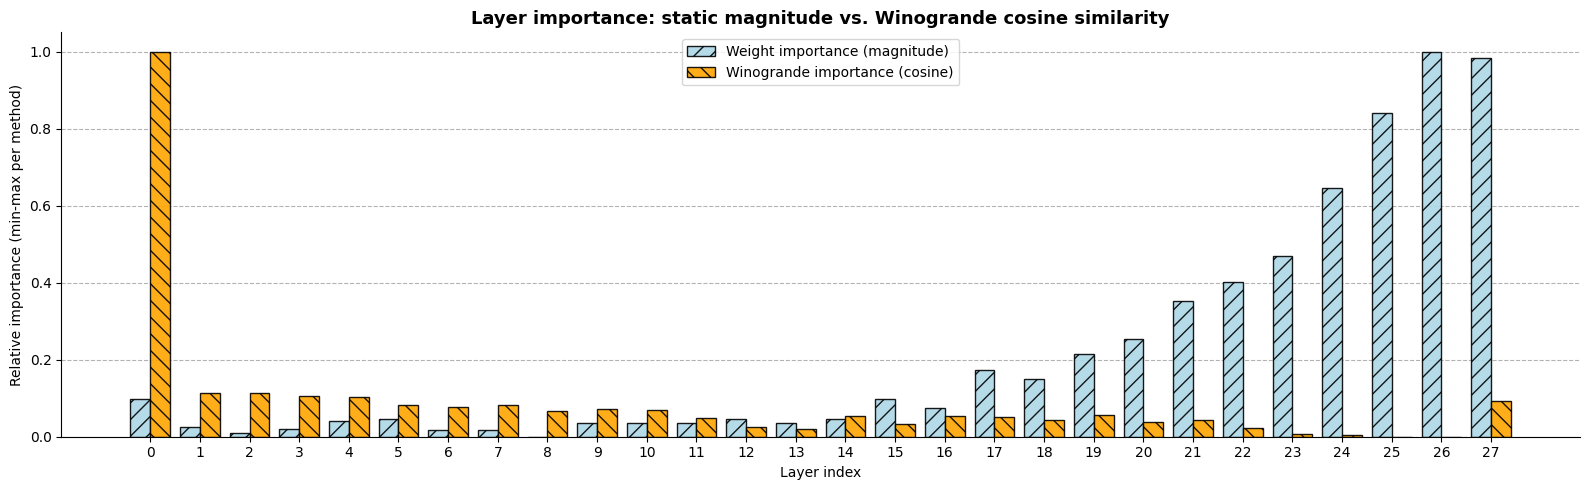

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

layers = list(range(len(model.model.layers)))
weight_vals = [weight_importance[i] for i in layers]
winogrande_vals  = [winogrande_importance[i]  for i in layers]

def minmax(values):
    lo, hi = min(values), max(values)
    return [(v - lo) / (hi - lo) for v in values]

weight_norm = minmax(weight_vals)
winogrande_norm  = minmax(winogrande_vals)

x     = np.arange(len(layers))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(x - width/2, weight_norm, width,
       label='Weight importance (magnitude)',
       color='lightblue', hatch='//', edgecolor='black', alpha=0.9)
ax.bar(x + width/2, winogrande_norm, width,
       label='Winogrande importance (cosine)',
       color='orange', hatch='\\\\', edgecolor='black', alpha=0.9)

ax.set_xlabel('Layer index')
ax.set_ylabel('Relative importance (min-max per method)')
ax.set_title('Layer importance: static magnitude vs. Winogrande cosine similarity',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

## Creating models using optipfair.

We'll create a function to select the blocks to delete.

This function can use the protection heuristic, always keeping the first four blocks and the last two. It will also avoid deleting two consecutive blocks.

In [ ]:
def select_layers_to_prune(importance_scores,
                            num_layers=2,
                            heuristic_protection=True,
                            adjacent_protection=True):
    """
    Select layers following best practices:
    - Non-consecutive
    - Distributed throughout the model
    - Avoid very early layers (0-2) and the last one (27)
    """
    # Order by importance
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])
    selected = []
    for layer, score in sorted_layers:
        # Skip protected layers
        if heuristic_protection and layer in [0, 1, 2, 3, 26, 27]:
            continue
        # Skip if adjacent
        if adjacent_protection and any(abs(layer - l) == 1 for l in selected):
            continue
        selected.append(layer)
        if len(selected) >= num_layers:
            break
    return selected

In [ ]:
winogrande_importance = calculate_layer_importance_cosine(model, dataloaderwinogrande, device)


Processing batches: 100%|██████████| 250/250 [00:26<00:00,  9.51it/s]


In [ ]:
# Prune with Winogrande calibration data
winogrande_layers_2_remove = select_layers_to_prune(winogrande_importance, num_layers=4, heuristic_protection=False, adjacent_protection=False)
print(f"Winogrande layers to remove: {winogrande_layers_2_remove}")


Winogrande layers to remove: [25, 26, 24, 23]


In [ ]:
winogrande_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=winogrande_layers_2_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 515089.96it/s]


In [ ]:
# Prune with Winogrande calibration data
winogrande_protected_layers_2_remove = select_layers_to_prune(winogrande_importance, num_layers=4, heuristic_protection=True, adjacent_protection=True)
print(f"Winogrande layers to remove: {winogrande_protected_layers_2_remove}")

Winogrande layers to remove: [25, 23, 13, 15]


In [ ]:
winogrande_model_protected = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=winogrande_protected_layers_2_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 519648.28it/s]


In [ ]:
# Additional static models requested for benchmark comparison
static_adjacent_protection_layers_removed = [11, 13, 15, 17]
static_last_layers_removed = [24, 25, 26, 27]
static_last_layer_protected_layers_removed = [23, 24, 25, 26]
static_last_layer_protected_2_layers_removed = [22, 23, 24, 25]

static_adjacent_protection_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=static_adjacent_protection_layers_removed,
    show_progress=True,
)

static_last_layers_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=static_last_layers_removed,
    show_progress=True,
)

static_last_layer_protected_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=static_last_layer_protected_layers_removed,
    show_progress=True,
)

static_last_layer_protected_2_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=static_last_layer_protected_2_layers_removed,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 521957.83it/s]


## 4.3.5 Analysis of the benchmarks

### lm_eval Evaluation

We keep a single lm_eval section and evaluate all models on the same benchmark set.

The comparison order is: base model, static pruned models, and Winogrande-pruned models.

Before running the full benchmark matrix, note the evaluation protocol used in this notebook:
- **Winogrande is evaluated with 5-shot** to align with Open LLM Leaderboard conventions and common reporting in the literature.
- **All other benchmarks are evaluated with 0-shot**.

In [ ]:
def model_evaluation(model_obj, tokenizer, tasks, limit=BENCHMARK_LIMIT):
    """
    Runs lm-eval on a PyTorch model object already in memory with task-specific few-shot settings.
    - winogrande: 5-shot
    - all other tasks: 0-shot
    Args:
        model_obj: The PyTorch model object to evaluate.
        tokenizer: The tokenizer object.
        tasks (list): A list of task names.
        limit (int): The number of samples per task.
    """
    print(f"Starting lm-eval on model '{model_obj.config._name_or_path}' for tasks: {tasks}")
    model_wrapper = HFLM(
        pretrained=model_obj,
        tokenizer=tokenizer,
        device=str(device)
    )

    formatted_results = {}
    for task_name in tasks:
        num_fewshot = 5 if task_name == 'winogrande' else 0
        print(f"  - Evaluating task '{task_name}' with {num_fewshot}-shot")
        results = evaluator.simple_evaluate(
            model=model_wrapper,
            tasks=[task_name],
            num_fewshot=num_fewshot,
            limit=limit,
            device=str(device),
        )

        res = results["results"][task_name]
        if 'acc,none' in res:
            metric_val = res.get('acc,none', 0)
        elif 'acc_norm,none' in res:
            metric_val = res.get('acc_norm,none', 0)
        elif 'ppl,none' in res:
            metric_val = res.get('ppl,none', 0)
        else:
            metric_val = 0
        formatted_results[task_name] = metric_val

    print(json.dumps({k: f"{v:.4f}" for k, v in formatted_results.items()}, indent=2))
    return formatted_results

os.environ["HF_ALLOW_CODE_EVAL"] = "1"

### General benchmarks

In [ ]:
os.environ["HF_ALLOW_CODE_EVAL"] = "1"

base_model_results = model_evaluation(model, tokenizer,
                                      BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_position_model_results = model_evaluation(pruned_model, tokenizer,
                                                 BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_magnitude_model_results = model_evaluation(magnitude_model,
                                                  tokenizer,
                                                  BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_adjacent_protection_model_results = model_evaluation(
    static_adjacent_protection_model, tokenizer, BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_last_layers_model_results = model_evaluation(
    static_last_layers_model, tokenizer, BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_last_layer_protected_model_results = model_evaluation(
    static_last_layer_protected_model, tokenizer, BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_last_layer_protected_2_model_results = model_evaluation(
    static_last_layer_protected_2_model, tokenizer, BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
winogrande_model_results = model_evaluation(winogrande_model,
                                            tokenizer,
                                            BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
winogrande_model_protected_results = model_evaluation(winogrande_model_protected,
                                                      tokenizer,
                                                      BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)

In [ ]:
print("=" * 50)
print("Base model")
print("=" * 50)
display(base_model_results)

print("\n" + "=" * 50)
print("Static pruned model - position (middle layers)")
print("=" * 50)
display(static_position_model_results)

print("\n" + "=" * 50)
print("Static pruned model - magnitude")
print("=" * 50)
display(static_magnitude_model_results)

print("\n" + "=" * 50)
print("Static pruned model - adjacent protection [11, 13, 15, 17]")
print("=" * 50)
display(static_adjacent_protection_model_results)

print("\n" + "=" * 50)
print("Static pruned model - last layers [24, 25, 26, 27]")
print("=" * 50)
display(static_last_layers_model_results)

print("\n" + "=" * 50)
print("Static pruned model - last layer protected [23, 24, 25, 26]")
print("=" * 50)
display(static_last_layer_protected_model_results)

print("\n" + "=" * 50)
print("Static pruned model - last layer protected 2 [22, 23, 24, 25]")
print("=" * 50)
display(static_last_layer_protected_2_model_results)

print("\n" + "=" * 50)
print("Winogrande pruned model")
print("=" * 50)
display(winogrande_model_results)

print("\n" + "=" * 50)
print("Winogrande pruned model (heuristic protection)")
print("=" * 50)
display(winogrande_model_protected_results)

Base model


{'winogrande': 0.5651144435674822,
 'boolq': 0.6443425076452599,
 'arc_easy': 0.6081649831649831,
 'hellaswag': 0.37532364070902213,
 'lambada_openai': 0.4034542984669125}


Static pruned model - position (middle layers)


{'winogrande': 0.5438042620363063,
 'boolq': 0.6214067278287462,
 'arc_easy': 0.5526094276094277,
 'hellaswag': 0.3314080860386377,
 'lambada_openai': 0.25732582961381717}


Static pruned model - magnitude


...

{'winogrande': 0.5485398579321231,
 'boolq': 0.6241590214067279,
 'arc_easy': 0.4305555555555556,
 'hellaswag': 0.3211511651065525,
 'lambada_openai': 0.2239472152144382}


Winogrande pruned model


{'winogrande': 0.5477505919494869,
 'boolq': 0.5663608562691131,
 'arc_easy': 0.37626262626262624,
 'hellaswag': 0.30252937661820356,
 'lambada_openai': 0.041141082864350864}


Winogrande pruned model (heuristic protection)


{'winogrande': 0.55327545382794,
 'boolq': 0.6217125382262997,
 'arc_easy': 0.5084175084175084,
 'hellaswag': 0.33260306711810395,
 'lambada_openai': 0.2953619250921793}

In [ ]:
from IPython.display import Markdown, display

# Retention metrics methodology:
# - Winogrande Retention (%): direct ratio of the model's Winogrande score vs. the base model's Winogrande score.
# - General Capabilities Retention (%): mean of per-task retention ratios across all benchmarks
#   except Winogrande (boolq, arc_easy, hellaswag, lambada_openai). Each task contributes equally
#   regardless of its absolute score range, avoiding implicit weighting by scale.

model_rows = [
    ("Base model", [], base_model_results),
    ("Static pruned model - position", static_position_layers_removed, static_position_model_results),
    ("Static pruned model - magnitude", layers_to_remove, static_magnitude_model_results),
    ("Static pruned model - adjacent protection", static_adjacent_protection_layers_removed, static_adjacent_protection_model_results),
    ("Static pruned model - last layers", static_last_layers_removed, static_last_layers_model_results),
    ("Static pruned model - last layer protected", static_last_layer_protected_layers_removed, static_last_layer_protected_model_results),
    ("Static pruned model - last layer protected 2", static_last_layer_protected_2_layers_removed, static_last_layer_protected_2_model_results),
    ("Winogrande pruned model", winogrande_layers_2_remove, winogrande_model_results),
    ("Winogrande pruned model - heuristic protection", winogrande_protected_layers_2_remove, winogrande_model_protected_results),
]

general_tasks = [t for t in BENCHMARK_TASKS if t != "winogrande"]
base_winogrande = base_model_results.get("winogrande", float("nan"))
base_general = {t: base_model_results.get(t, float("nan")) for t in general_tasks}

header = "| Model | Removed Layers | " + " | ".join(BENCHMARK_TASKS) + " | Winogrande Ret. (%) | General Ret. (%) |"
separator = "|---|---" + "|---" * len(BENCHMARK_TASKS) + "|---|---|"
rows = []

for model_name, removed_layers, result_dict in model_rows:
    metric_values = [f"{result_dict.get(task, float('nan')):.4f}" for task in BENCHMARK_TASKS]

    winogrande_score = result_dict.get("winogrande", float("nan"))
    winogrande_retention = (winogrande_score / base_winogrande) * 100

    general_retentions = [
        (result_dict.get(t, float("nan")) / base_general[t]) * 100
        for t in general_tasks
    ]
    general_retention = sum(general_retentions) / len(general_retentions)

    rows.append(
        "| " + model_name + " | " + str(removed_layers) + " | " +
        " | ".join(metric_values) +
        f" | {winogrande_retention:.1f}% | {general_retention:.1f}% |"
    )

markdown_table = "\n".join([header, separator] + rows)
display(Markdown(markdown_table))

| Model | Removed Layers | winogrande | boolq | arc_easy | hellaswag | lambada_openai | Winogrande Ret. (%) | General Ret. (%) |
|---|---|---|---|---|---|---|---|---|
| Base model | [] | 0.5651 | 0.6443 | 0.6082 | 0.3753 | 0.4035 | 100.0% | 100.0% |
| Static pruned model - position | [12, 13, 14, 15] | 0.5438 | 0.6214 | 0.5526 | 0.3314 | 0.2573 | 96.2% | 84.8% |
| Static pruned model - magnitude | [8, 2, 7, 6] | 0.5012 | 0.4312 | 0.2807 | 0.2652 | 0.0128 | 88.7% | 46.7% |
| Static pruned model - adjacent protection | [11, 13, 15, 17] | 0.5051 | 0.5024 | 0.5564 | 0.3224 | 0.1393 | 89.4% | 72.5% |
| Static pruned model - last layers | [24, 25, 26, 27] | 0.5217 | 0.6220 | 0.4853 | 0.3287 | 0.0363 | 92.3% | 68.2% |
| Static pruned model - last layer protected | [23, 24, 25, 26] | 0.5478 | 0.5664 | 0.3763 | 0.3025 | 0.0411 | 96.9% | 60.1% |
| Static pruned model - last layer protected 2 | [22, 23, 24, 25] | 0.5485 | 0.6242 | 0.4306 | 0.3212 | 0.2239 | 97.1% | 77.2% |
| Winogrande pruned model | [25, 26, 24, 23] | 0.5478 | 0.5664 | 0.3763 | 0.3025 | 0.0411 | 96.9% | 60.1% |
| Winogrande pruned model - heuristic protection | [25, 23, 13, 15] | 0.5533 | 0.6217 | 0.5084 | 0.3326 | 0.2954 | 97.9% | 85.5% |

### Measuring Inference Performance Benchmarks

Now we'll measure the inference performance of the pruned models and compare them with the base model. We'll measure:

- **Inference Time**: Total time to process multiple prompts
- **Time to First Token (TTFT)**: Time from input to first generated token
- **Throughput**: Tokens generated per second

In [ ]:
import gc
import time

def clear_gpu_cache():
    """Clear GPU cache completely"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 50) -> str:
    """Generate text with the model"""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            num_return_sequences=1,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=3,
            no_repeat_ngram_size=2
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
from transformers import StoppingCriteria, StoppingCriteriaList

# Callback class to capture time to first token
class FirstTokenTimeLogger(StoppingCriteria):
    def __init__(self, device):
        self.start_time = time.time()
        self.ttft = None
        self.device = device

    def __call__(self, input_ids, scores, **kwargs):
        # Sync for accurate GPU measurement
        torch.cuda.synchronize(self.device)
        if self.ttft is None:
            # Capture time on the first call (after first token)
            self.ttft = time.time() - self.start_time
        return False  # Return False to not stop generation

def measure_detailed_performance(model, tokenizer, data_source, num_runs=3,
                                 max_new_tokens=50, max_samples=None):
    """
    Measure TTFT and throughput.
    Args:
        data_source: List of prompts (strings) OR DataLoader
        max_samples: Limit number of samples (None = all)
    """
    device = model.device

    # Check if data_source is a DataLoader
    is_dataloader = hasattr(data_source, '__iter__') and hasattr(data_source,
                                                                 'dataset')

    # Extract prompts
    if is_dataloader:
        prompts = []
        for i, batch in enumerate(data_source):
            if max_samples and len(prompts) >= max_samples:
                break
            # Decode batch to text
            input_ids = batch['input_ids']
            for ids in input_ids:
                if max_samples and len(prompts) >= max_samples:
                    break
                ids_no_pad = ids[ids != tokenizer.pad_token_id]
                if len(ids_no_pad) > 0:  # Skip empty sequences
                    prompt = tokenizer.decode(ids_no_pad, skip_special_tokens=True)
                    if prompt.strip():  # Skip empty strings
                        prompts.append(prompt)
    else:
        prompts = data_source

    times = []
    ttfts = []
    throughputs = []

    # Warmup
    print("Warming up model...")
    for _ in range(10):
        inputs = tokenizer("warmup", return_tensors='pt').to(device)
        _ = model.generate(inputs.input_ids, max_new_tokens=max_new_tokens,
                           do_sample=False, pad_token_id=tokenizer.pad_token_id)
    torch.cuda.synchronize(device)

    print(f"Starting measurement with {len(prompts)} prompts...")
    for run in range(num_runs):
        run_times = []
        run_ttfts = []
        run_tokens = []
        for prompt in prompts:
            inputs = tokenizer(prompt, return_tensors='pt').to(device)
            # Skip if input is too short
            if inputs['input_ids'].shape[1] < 2:
                continue
            time_logger = FirstTokenTimeLogger(device)
            torch.cuda.synchronize(device)
            gen_start = time.time()
            with torch.no_grad():
                outputs = model.generate(
                    inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_new_tokens=max_new_tokens,
                    pad_token_id=tokenizer.pad_token_id,
                    stopping_criteria=StoppingCriteriaList([time_logger]),
                    do_sample=False,
                )
            torch.cuda.synchronize(device)
            gen_end = time.time()
            total_time = gen_end - gen_start
            num_tokens = outputs.shape[1] - inputs['input_ids'].shape[1]
            run_times.append(total_time)
            run_ttfts.append(time_logger.ttft)
            run_tokens.append(num_tokens)
        times.append(np.mean(run_times))
        ttfts.append(np.mean(run_ttfts))
        throughputs.append(np.sum(run_tokens) / np.sum(run_times))

    return {
        'mean_time_per_prompt': np.mean(times),
        'std_time_per_prompt': np.std(times),
        'mean_ttft': np.mean(ttfts),
        'std_ttft': np.std(ttfts),
        'mean_throughput_tokens_sec': np.mean(throughputs),
        'std_throughput_tokens_sec': np.std(throughputs)
    }

In [ ]:
# With Winogrande dataloader
print("Measuring base model on Winogrande...")
base_winogrande_timing = measure_detailed_performance(model, tokenizer,
                                                      dataloaderwinogrande, max_samples=10)

print("\nMeasuring winogrande_model on Winogrande...")
winogrande_timing = measure_detailed_performance(winogrande_model, tokenizer,
                                                 dataloaderwinogrande, max_samples=10)

winogrande_speedup = base_winogrande_timing['mean_time_per_prompt'] / winogrande_timing['mean_time_per_prompt']
print(f"\nWinogrande Model Speedup: {winogrande_speedup:.2f}x")

print("\nMeasuring winogrande_model_protected on Winogrande...")
winogrande_protected_timing = measure_detailed_performance(winogrande_model_protected,
                                                           tokenizer,
                                                           dataloaderwinogrande,
                                                           max_samples=10)

winogrande_protected_speedup = base_winogrande_timing['mean_time_per_prompt'] / winogrande_protected_timing['mean_time_per_prompt']
print(f"\nWinogrande Protected Model Speedup: {winogrande_protected_speedup:.2f}x")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Measuring base model on Winogrande...
Warming up model...
Starting measurement with 10 prompts...

Measuring winogrande_model on Winogrande...
Warming up model...
Starting measurement with 10 prompts...

Winogrande Model Speedup: 1.17x

Measuring winogrande_model_protected on Winogrande...
Warming up model...
Starting measurement with 10 prompts...

Winogrande Protected Model Speedup: 1.17x


In [ ]:
# Calculate speedups for inference time
winogrande_time_reduction = (base_winogrande_timing['mean_time_per_prompt'] - winogrande_timing['mean_time_per_prompt']) / base_winogrande_timing['mean_time_per_prompt'] * 100
winogrande_protected_time_reduction = (base_winogrande_timing['mean_time_per_prompt'] - winogrande_protected_timing['mean_time_per_prompt']) / base_winogrande_timing['mean_time_per_prompt'] * 100

# Calculate speedups for TTFT (lower is better)
winogrande_ttft_speedup = base_winogrande_timing['mean_ttft'] / winogrande_timing['mean_ttft']
winogrande_protected_ttft_speedup = base_winogrande_timing['mean_ttft'] / winogrande_protected_timing['mean_ttft']
winogrande_ttft_reduction = (base_winogrande_timing['mean_ttft'] - winogrande_timing['mean_ttft']) / base_winogrande_timing['mean_ttft'] * 100
winogrande_protected_ttft_reduction = (base_winogrande_timing['mean_ttft'] - winogrande_protected_timing['mean_ttft']) / base_winogrande_timing['mean_ttft'] * 100

# Calculate speedups for Throughput (higher is better)
winogrande_throughput_speedup = winogrande_timing['mean_throughput_tokens_sec'] / base_winogrande_timing['mean_throughput_tokens_sec']
winogrande_protected_throughput_speedup = winogrande_protected_timing['mean_throughput_tokens_sec'] / base_winogrande_timing['mean_throughput_tokens_sec']
winogrande_throughput_improvement = (winogrande_timing['mean_throughput_tokens_sec'] - base_winogrande_timing['mean_throughput_tokens_sec']) / base_winogrande_timing['mean_throughput_tokens_sec'] * 100
winogrande_protected_throughput_improvement = (winogrande_protected_timing['mean_throughput_tokens_sec'] - base_winogrande_timing['mean_throughput_tokens_sec']) / base_winogrande_timing['mean_throughput_tokens_sec'] * 100

print(f"\nPerformance Benchmark Results:\n")
print("=" * 70)
print("Base Model (Winogrande prompts):")
print(f"  Inference Time: {base_winogrande_timing['mean_time_per_prompt']:.3f}s ± {base_winogrande_timing['std_time_per_prompt']:.3f}s")
print(f"  TTFT: {base_winogrande_timing['mean_ttft']*1000:.2f}ms ± {base_winogrande_timing['std_ttft']*1000:.2f}ms")
print(f"  Throughput: {base_winogrande_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {base_winogrande_timing['std_throughput_tokens_sec']:.2f}")
print("=" * 70)
print("Winogrande Model (pruned):")
print(f"  Inference Time: {winogrande_timing['mean_time_per_prompt']:.3f}s ± {winogrande_timing['std_time_per_prompt']:.3f}s")
print(f"    -> Speedup: {winogrande_speedup:.2f}x ({winogrande_time_reduction:+.1f}%)")
print(f"  TTFT: {winogrande_timing['mean_ttft']*1000:.2f}ms ± {winogrande_timing['std_ttft']*1000:.2f}ms")
print(f"    -> Speedup: {winogrande_ttft_speedup:.2f}x ({winogrande_ttft_reduction:+.1f}%)")
print(f"  Throughput: {winogrande_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {winogrande_timing['std_throughput_tokens_sec']:.2f}")
print(f"    -> Speedup: {winogrande_throughput_speedup:.2f}x ({winogrande_throughput_improvement:+.1f}%)")
print("=" * 70)
print("Winogrande Model (pruned, heuristic protection):")
print(f"  Inference Time: {winogrande_protected_timing['mean_time_per_prompt']:.3f}s ± {winogrande_protected_timing['std_time_per_prompt']:.3f}s")
print(f"    -> Speedup: {winogrande_protected_speedup:.2f}x ({winogrande_protected_time_reduction:+.1f}%)")
print(f"  TTFT: {winogrande_protected_timing['mean_ttft']*1000:.2f}ms ± {winogrande_protected_timing['std_ttft']*1000:.2f}ms")
print(f"    -> Speedup: {winogrande_protected_ttft_speedup:.2f}x ({winogrande_protected_ttft_reduction:+.1f}%)")
print(f"  Throughput: {winogrande_protected_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {winogrande_protected_timing['std_throughput_tokens_sec']:.2f}")
print(f"    -> Speedup: {winogrande_protected_throughput_speedup:.2f}x ({winogrande_protected_throughput_improvement:+.1f}%)")


Performance Benchmark Results:

Base Model (Winogrande prompts):
  Inference Time: 2.099s ± 0.008s
  TTFT: 45.91ms ± 0.12ms
  Throughput: 23.82 tokens/s ± 0.09
Winogrande Model (pruned):
  Inference Time: 1.793s ± 0.005s
    -> Speedup: 1.17x (+14.6%)
  TTFT: 39.82ms ± 0.62ms
    -> Speedup: 1.15x (+13.3%)
  Throughput: 27.89 tokens/s ± 0.08
    -> Speedup: 1.17x (+17.1%)
Winogrande Model (pruned, heuristic protection):
  Inference Time: 1.796s ± 0.007s
    -> Speedup: 1.17x (+14.4%)
  TTFT: 39.89ms ± 0.64ms
    -> Speedup: 1.15x (+13.1%)
  Throughput: 27.84 tokens/s ± 0.11
    -> Speedup: 1.17x (+16.9%)
